# ============================================================
# Predictive Maintenance EDA
# Dataset: Microsoft Azure PdM (Kaggle)
# Objetivo: entender distribuciones, patrones temporales,
#           desbalance de clases y correlaciones antes de
#           construir el pipeline de entrenamiento.
# ============================================================

In [38]:
import warnings
warnings.filterwarnings("ignore")

from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import polars as pl
import polars.selectors as cs

# Estilo limpio para todas las gráficas
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print("Polars version:", pl.__version__)
print("Data path:", DATA_RAW.resolve())

Polars version: 1.40.1
Data path: C:\Users\harryson.guerrero\OneDrive - Softtek\Documentos\Walmart\pdm-ml\data\raw


In [23]:
# ── Carga de los 5 datasets ───────────────────────────────────────────────
telemetry = pl.read_csv(DATA_RAW / "PdM_telemetry.csv",  try_parse_dates=True)
errors    = pl.read_csv(DATA_RAW / "PdM_errors.csv",     try_parse_dates=True)
maint     = pl.read_csv(DATA_RAW / "PdM_maint.csv",      try_parse_dates=True)
failures  = pl.read_csv(DATA_RAW / "PdM_failures.csv",   try_parse_dates=True)
machines  = pl.read_csv(DATA_RAW / "PdM_machines.csv")

for name, df in [
    ("telemetry", telemetry),
    ("errors",    errors),
    ("maint",     maint),
    ("failures",  failures),
    ("machines",  machines),
]:
    print(f"{name:12s} → {df.shape[0]:>7,} rows × {df.shape[1]} cols")

telemetry    → 876,100 rows × 6 cols
errors       →   3,919 rows × 3 cols
maint        →   3,286 rows × 3 cols
failures     →     761 rows × 3 cols
machines     →     100 rows × 3 cols


In [24]:
# ── Schema de cada tabla ─────────────────────────────────────────────────
for name, df in [
    ("telemetry", telemetry),
    ("errors",    errors),
    ("maint",     maint),
    ("failures",  failures),
    ("machines",  machines),
]:
    print(f"\n{'='*40}")
    print(f"  {name.upper()}")
    print(f"{'='*40}")
    print(df.schema)
    print(df.head(3))


  TELEMETRY
Schema({'datetime': Datetime(time_unit='us', time_zone=None), 'machineID': Int64, 'volt': Float64, 'rotate': Float64, 'pressure': Float64, 'vibration': Float64})
shape: (3, 6)
┌─────────────────────┬───────────┬────────────┬────────────┬────────────┬───────────┐
│ datetime            ┆ machineID ┆ volt       ┆ rotate     ┆ pressure   ┆ vibration │
│ ---                 ┆ ---       ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│ datetime[μs]        ┆ i64       ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
╞═════════════════════╪═══════════╪════════════╪════════════╪════════════╪═══════════╡
│ 2015-01-01 06:00:00 ┆ 1         ┆ 176.217853 ┆ 418.504078 ┆ 113.077935 ┆ 45.087686 │
│ 2015-01-01 07:00:00 ┆ 1         ┆ 162.879223 ┆ 402.74749  ┆ 95.460525  ┆ 43.413973 │
│ 2015-01-01 08:00:00 ┆ 1         ┆ 170.989902 ┆ 527.349825 ┆ 75.237905  ┆ 34.178847 │
└─────────────────────┴───────────┴────────────┴────────────┴────────────┴───────────┘

  ERRORS
Schema({'datetime'

In [25]:
# ── Estadísticas descriptivas — sensores ─────────────────────────────────
sensors = ["volt", "rotate", "pressure", "vibration"]

print("TELEMETRY — Descriptive Statistics")
print("=" * 60)
print(telemetry.select(sensors).describe())

# Verificar valores faltantes
print("\nNull counts:")
print(telemetry.select(sensors).null_count())

TELEMETRY — Descriptive Statistics
shape: (9, 5)
┌────────────┬────────────┬────────────┬────────────┬───────────┐
│ statistic  ┆ volt       ┆ rotate     ┆ pressure   ┆ vibration │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│ str        ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
╞════════════╪════════════╪════════════╪════════════╪═══════════╡
│ count      ┆ 876100.0   ┆ 876100.0   ┆ 876100.0   ┆ 876100.0  │
│ null_count ┆ 0.0        ┆ 0.0        ┆ 0.0        ┆ 0.0       │
│ mean       ┆ 170.777736 ┆ 446.605119 ┆ 100.858668 ┆ 40.385007 │
│ std        ┆ 15.509114  ┆ 52.673886  ┆ 11.048679  ┆ 5.370361  │
│ min        ┆ 97.333604  ┆ 138.432075 ┆ 51.237106  ┆ 14.877054 │
│ 25%        ┆ 160.304961 ┆ 412.305749 ┆ 93.49819   ┆ 36.7773   │
│ 50%        ┆ 170.607343 ┆ 447.558205 ┆ 100.425578 ┆ 40.237247 │
│ 75%        ┆ 181.004492 ┆ 482.176586 ┆ 107.555224 ┆ 43.784935 │
│ max        ┆ 255.124717 ┆ 695.020984 ┆ 185.951998 ┆ 76.791072 │
└────────────┴────────────┴

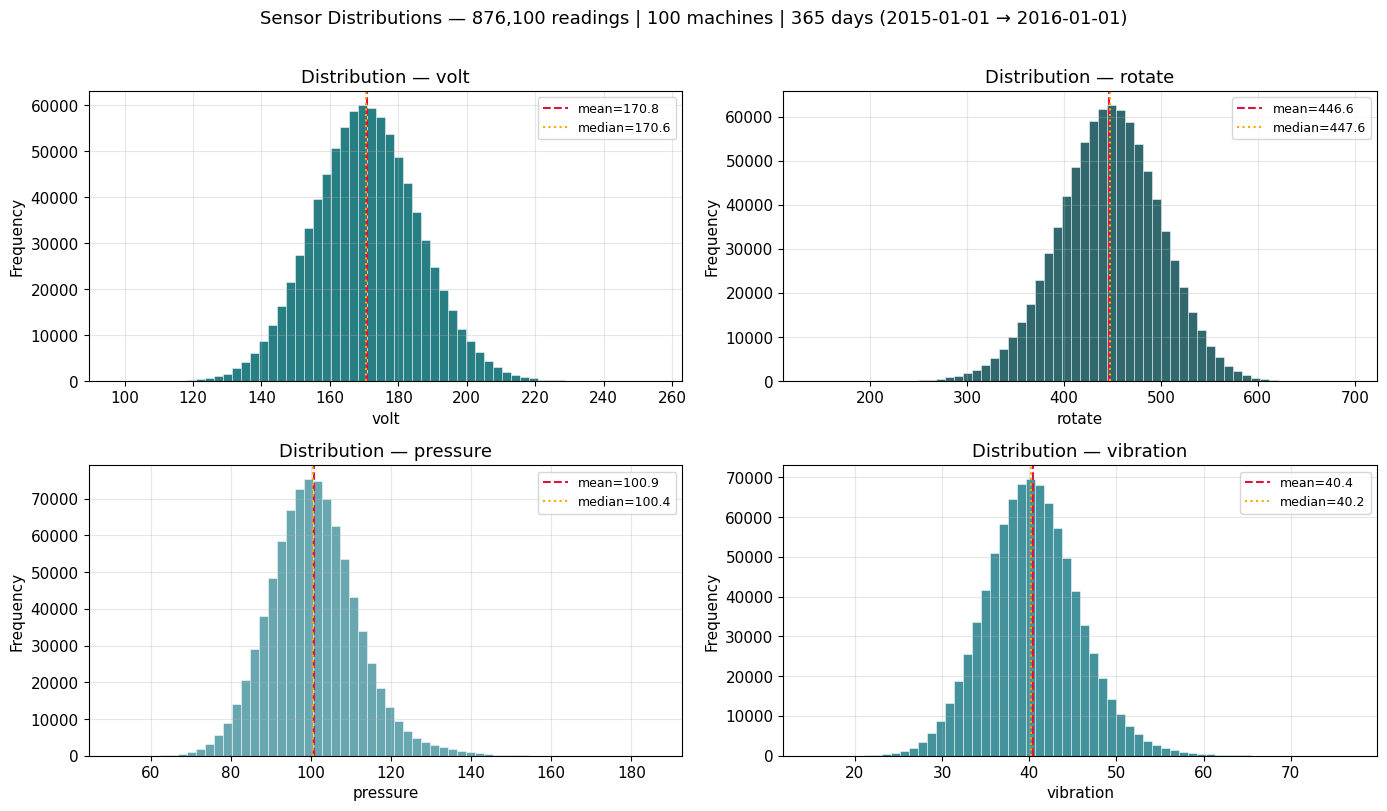

In [39]:
# ── Derivar metadata del dato, nunca hardcodear ───────────────────────────
n_total_rows  = telemetry.shape[0]
n_machines    = telemetry["machineID"].n_unique()
date_start    = telemetry["datetime"].min()
date_end      = telemetry["datetime"].max()
span_days     = (date_end - date_start).days

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

colors = ["#01696f", "#0c4e54", "#4f98a3", "#227f8b"]

for i, (sensor, color) in enumerate(zip(sensors, colors)):
    vals = telemetry[sensor].to_numpy()
    axes[i].hist(vals, bins=60, color=color, alpha=0.85, edgecolor="white", linewidth=0.4)
    axes[i].axvline(
        np.mean(vals), color="crimson", linestyle="--",
        linewidth=1.5, label=f"mean={np.mean(vals):.1f}"
    )
    axes[i].axvline(
        np.median(vals), color="orange", linestyle=":",
        linewidth=1.5, label=f"median={np.median(vals):.1f}"
    )
    axes[i].set_title(f"Distribution — {sensor}")
    axes[i].set_xlabel(sensor)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=9)

# ✅ Título construido desde variables derivadas del dato
plt.suptitle(
    f"Sensor Distributions — {n_total_rows:,} readings | "
    f"{n_machines} machines | "
    f"{span_days} days "
    f"({date_start.strftime('%Y-%m-%d')} → {date_end.strftime('%Y-%m-%d')})",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_sensor_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
# ── Derivar granularidad del dato ─────────────────────────────────────────
sample_machine = (
    telemetry
    .filter(pl.col("machineID") == telemetry["machineID"].min())
    .sort("datetime")
)
granularity_td    = sample_machine["datetime"][1] - sample_machine["datetime"][0]
granularity_hours = granularity_td.seconds // 3600
avg_per_machine   = telemetry.shape[0] // n_machines

print("Telemetry time range:")
print(f"  Start       : {date_start}")
print(f"  End         : {date_end}")
print(f"  Span        : ~{span_days} days")
print(f"  Granularity : {granularity_td} ({granularity_hours}h per reading)")
print(f"\nMachines  : {n_machines} unique")
print(f"Readings  : {telemetry.shape[0]:,} total ({avg_per_machine:,} per machine avg)")

coverage = (
    telemetry
    .group_by("machineID")
    .agg([
        pl.col("datetime").min().alias("start"),
        pl.col("datetime").max().alias("end"),
        pl.len().alias("n_readings"),
    ])
    .sort("machineID")
)
print("\nPer-machine coverage (sample):")
print(coverage.head(10))
print(f"\nAll machines same n_readings: {coverage['n_readings'].n_unique() == 1}")

Telemetry time range:
  Start       : 2015-01-01 06:00:00
  End         : 2016-01-01 06:00:00
  Span        : ~365 days
  Granularity : 1:00:00 (1h per reading)

Machines  : 100 unique
Readings  : 876,100 total (8,761 per machine avg)

Per-machine coverage (sample):
shape: (10, 4)
┌───────────┬─────────────────────┬─────────────────────┬────────────┐
│ machineID ┆ start               ┆ end                 ┆ n_readings │
│ ---       ┆ ---                 ┆ ---                 ┆ ---        │
│ i64       ┆ datetime[μs]        ┆ datetime[μs]        ┆ u32        │
╞═══════════╪═════════════════════╪═════════════════════╪════════════╡
│ 1         ┆ 2015-01-01 06:00:00 ┆ 2016-01-01 06:00:00 ┆ 8761       │
│ 2         ┆ 2015-01-01 06:00:00 ┆ 2016-01-01 06:00:00 ┆ 8761       │
│ 3         ┆ 2015-01-01 06:00:00 ┆ 2016-01-01 06:00:00 ┆ 8761       │
│ 4         ┆ 2015-01-01 06:00:00 ┆ 2016-01-01 06:00:00 ┆ 8761       │
│ 5         ┆ 2015-01-01 06:00:00 ┆ 2016-01-01 06:00:00 ┆ 8761       │
│ 6     

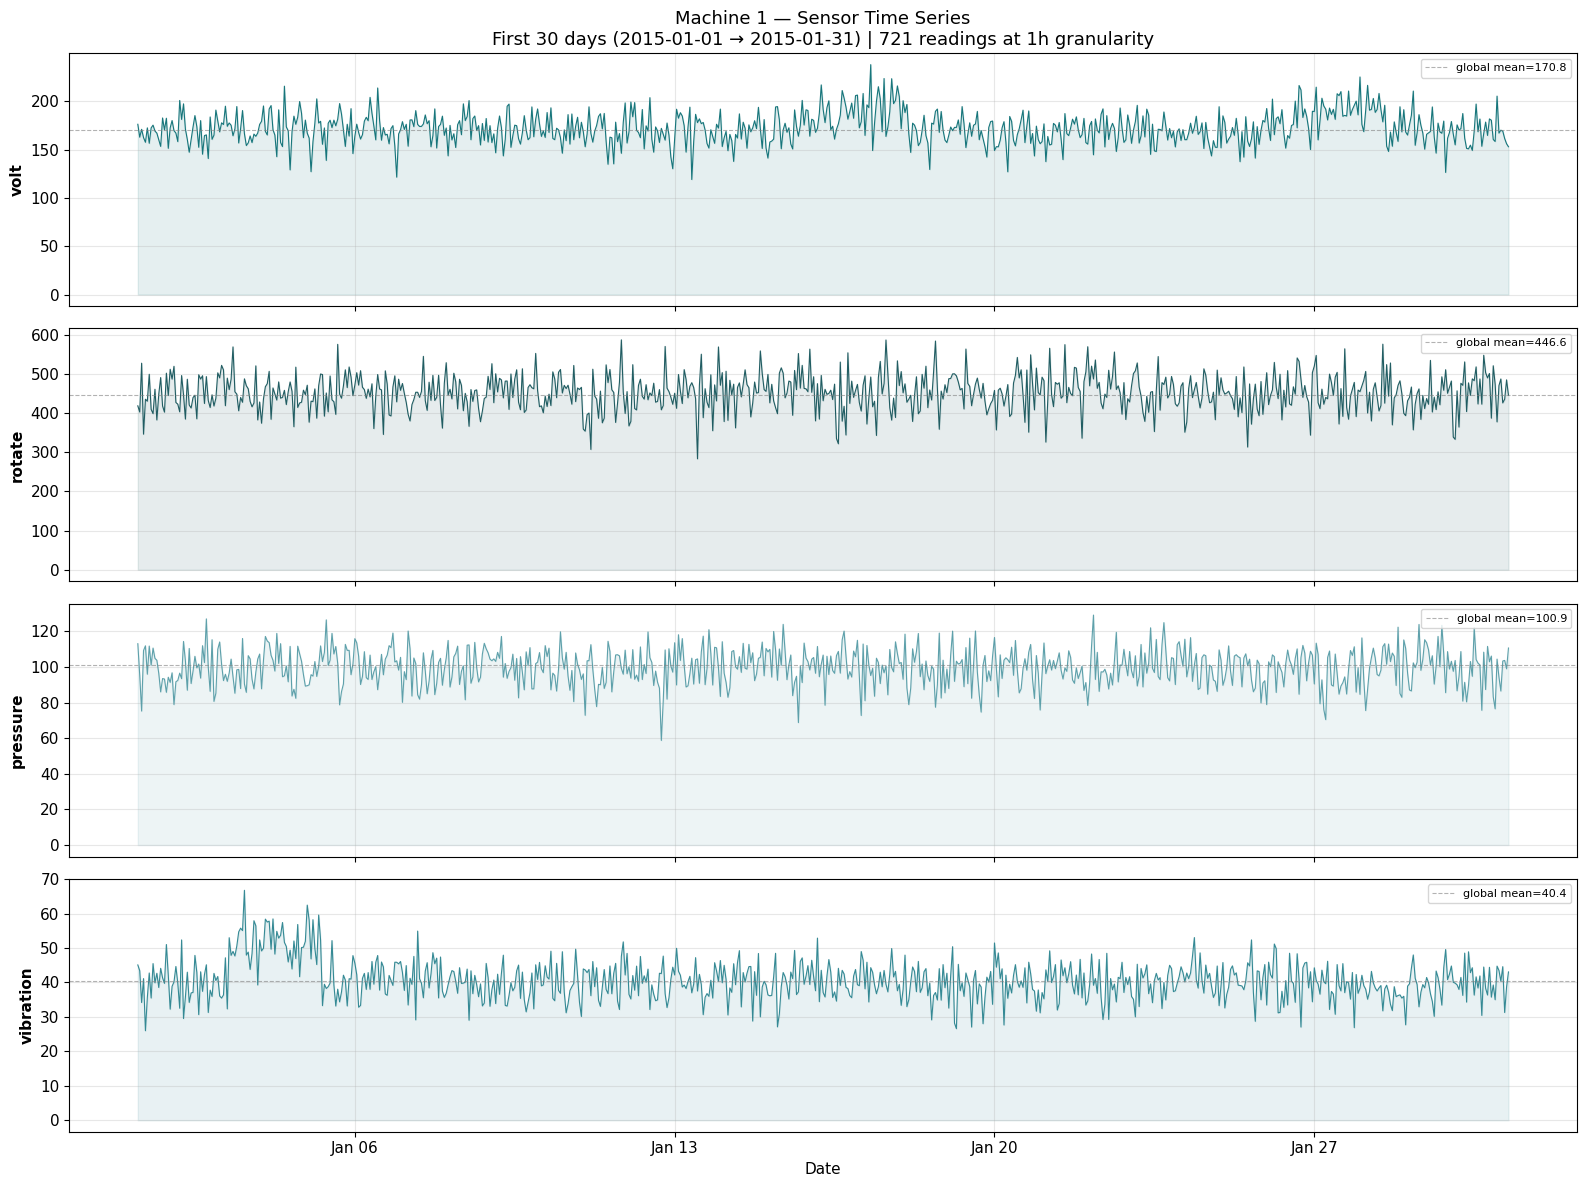

In [41]:
# ── Derivar ventana de visualización del dato ─────────────────────────────
VIZ_DAYS     = 30
machine_id   = telemetry["machineID"].min()   # primera máquina disponible
machine_data = telemetry.filter(pl.col("machineID") == machine_id).sort("datetime")
start_dt     = machine_data["datetime"][0]
end_dt       = start_dt + timedelta(days=VIZ_DAYS)

sample       = machine_data.filter(pl.col("datetime") <= end_dt)
n_rows_shown = sample.shape[0]

dts  = sample["datetime"].to_list()
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

for ax, sensor, color in zip(axes, sensors, colors):
    vals = sample[sensor].to_numpy()
    ax.plot(dts, vals, linewidth=0.8, color=color, alpha=0.9)
    ax.fill_between(dts, vals, alpha=0.1, color=color)
    sensor_mean = float(telemetry[sensor].mean())
    ax.axhline(sensor_mean, color="gray", linestyle="--", linewidth=0.8, alpha=0.6,
               label=f"global mean={sensor_mean:.1f}")
    ax.set_ylabel(sensor, fontweight="bold")
    ax.legend(fontsize=8, loc="upper right")

# ✅ Título y subtítulo derivados del dato
axes[0].set_title(
    f"Machine {machine_id} — Sensor Time Series\n"
    f"First {VIZ_DAYS} days ({start_dt.strftime('%Y-%m-%d')} → {end_dt.strftime('%Y-%m-%d')}) "
    f"| {n_rows_shown:,} readings at {granularity_hours}h granularity",
    fontsize=13
)
axes[-1].set_xlabel("Date")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_timeseries_machine1.png", dpi=150, bbox_inches="tight")
plt.show()

Error types       : 5
Total error events: 3,919
Machines affected : 100 / 100
shape: (5, 2)
┌─────────┬───────┐
│ errorID ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ error1  ┆ 1010  │
│ error2  ┆ 988   │
│ error3  ┆ 838   │
│ error4  ┆ 727   │
│ error5  ┆ 356   │
└─────────┴───────┘


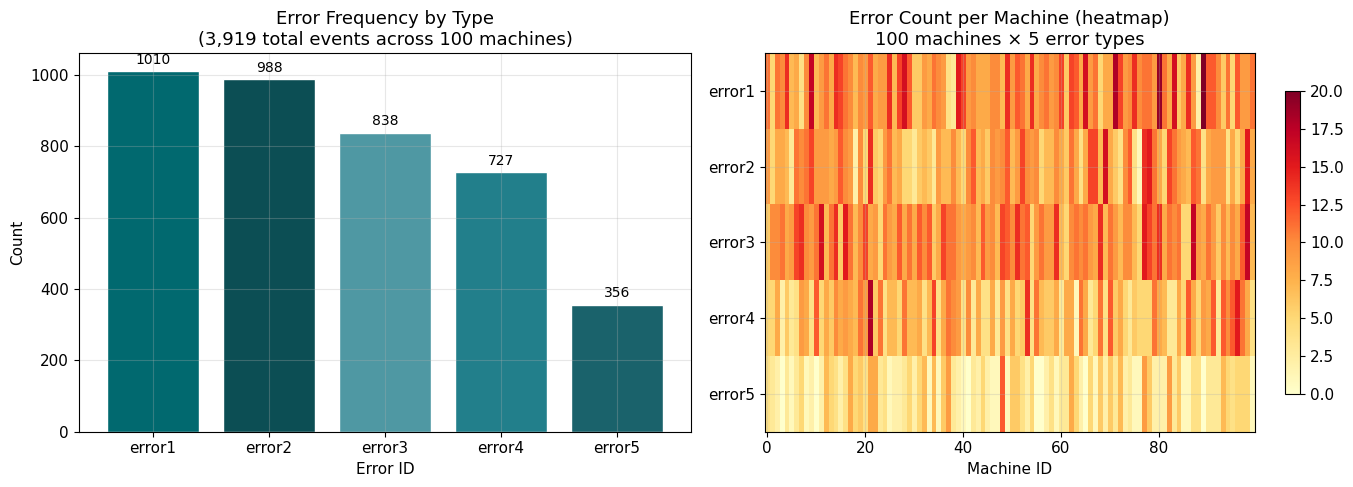

In [42]:
error_counts = (
    errors
    .group_by("errorID")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
n_error_types   = error_counts.shape[0]
total_errors    = errors.shape[0]
machines_w_err  = errors["machineID"].n_unique()

print(f"Error types       : {n_error_types}")
print(f"Total error events: {total_errors:,}")
print(f"Machines affected : {machines_w_err} / {n_machines}")
print(error_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
eids = error_counts["errorID"].to_list()
cnts = error_counts["count"].to_list()
palette = ["#01696f","#0c4e54","#4f98a3","#227f8b","#1a626b"][:n_error_types]
bars = ax.bar(eids, cnts, color=palette, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3, fontsize=10)
# ✅ Título derivado del dato
ax.set_title(f"Error Frequency by Type\n({total_errors:,} total events across {machines_w_err} machines)")
ax.set_xlabel("Error ID")
ax.set_ylabel("Count")

ax = axes[1]
err_machine = (
    errors
    .group_by(["machineID", "errorID"])
    .agg(pl.len().alias("count"))
    .pivot(on="errorID", index="machineID", values="count")
    .fill_null(0)
    .sort("machineID")
)
err_matrix = err_machine.select([c for c in err_machine.columns if c != "machineID"]).to_numpy()
im = ax.imshow(err_matrix.T, aspect="auto", cmap="YlOrRd")
ax.set_yticks(range(len(eids)))
ax.set_yticklabels(eids)
ax.set_xlabel("Machine ID")
# ✅ Título derivado del dato
ax.set_title(f"Error Count per Machine (heatmap)\n{n_machines} machines × {n_error_types} error types")
plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

Total failure events : 761
Machines with failures: 98 / 100
Component types      : 4
Raw positive rate    : 0.087%
shape: (4, 2)
┌─────────┬───────┐
│ failure ┆ count │
│ ---     ┆ ---   │
│ str     ┆ u32   │
╞═════════╪═══════╡
│ comp2   ┆ 259   │
│ comp1   ┆ 192   │
│ comp4   ┆ 179   │
│ comp3   ┆ 131   │
└─────────┴───────┘


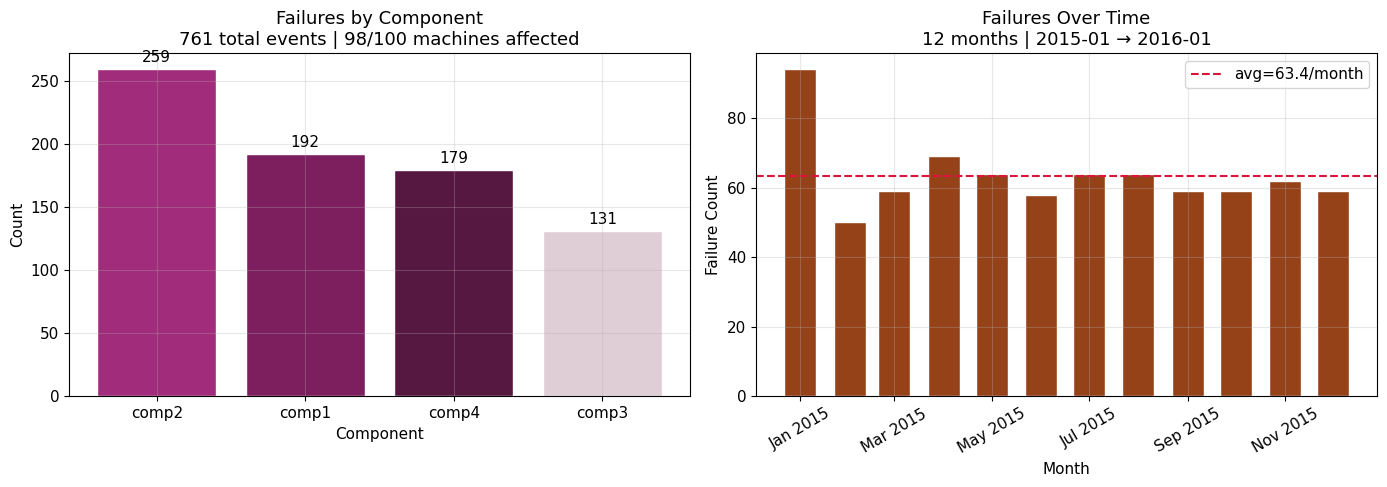

In [47]:
fail_dist = (
    failures
    .group_by("failure")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
n_failure_events   = failures.shape[0]
n_machines_failed  = failures["machineID"].n_unique()
n_components       = fail_dist.shape[0]
raw_positive_rate  = n_failure_events / telemetry.shape[0] * 100

print(f"Total failure events : {n_failure_events}")
print(f"Machines with failures: {n_machines_failed} / {n_machines}")
print(f"Component types      : {n_components}")
print(f"Raw positive rate    : {raw_positive_rate:.3f}%")
print(fail_dist)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
comps = fail_dist["failure"].to_list()
cnts  = fail_dist["count"].to_list()
pal   = ["#a12c7b","#7d1e5e","#561740","#e0ced7"][:n_components]
bars  = ax.bar(comps, cnts, color=pal, edgecolor="white")
ax.bar_label(bars, fmt="%d", padding=3)
# ✅ Título derivado del dato
ax.set_title(
    f"Failures by Component\n"
    f"{n_failure_events} total events | {n_machines_failed}/{n_machines} machines affected"
)
ax.set_xlabel("Component")
ax.set_ylabel("Count")

ax = axes[1]
fail_monthly = (
    failures
    .with_columns(pl.col("datetime").dt.truncate("1mo").alias("month"))
    .group_by("month")
    .agg(pl.len().alias("count"))
    .sort("month")
)
n_months = fail_monthly.shape[0]
months   = fail_monthly["month"].to_list()
counts   = fail_monthly["count"].to_list()
avg_monthly = sum(counts) / n_months
ax.bar(months, counts, color="#964219", width=20, edgecolor="white")
ax.axhline(avg_monthly, color="crimson", linestyle="--", linewidth=1.5,
           label=f"avg={avg_monthly:.1f}/month")
ax.legend()
# ✅ Título derivado del dato
ax.set_title(
    f"Failures Over Time\n"
    f"{n_months} months | {date_start.strftime('%Y-%m')} → {date_end.strftime('%Y-%m')}"
)
ax.set_xlabel("Month")
ax.set_ylabel("Failure Count")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_failure_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

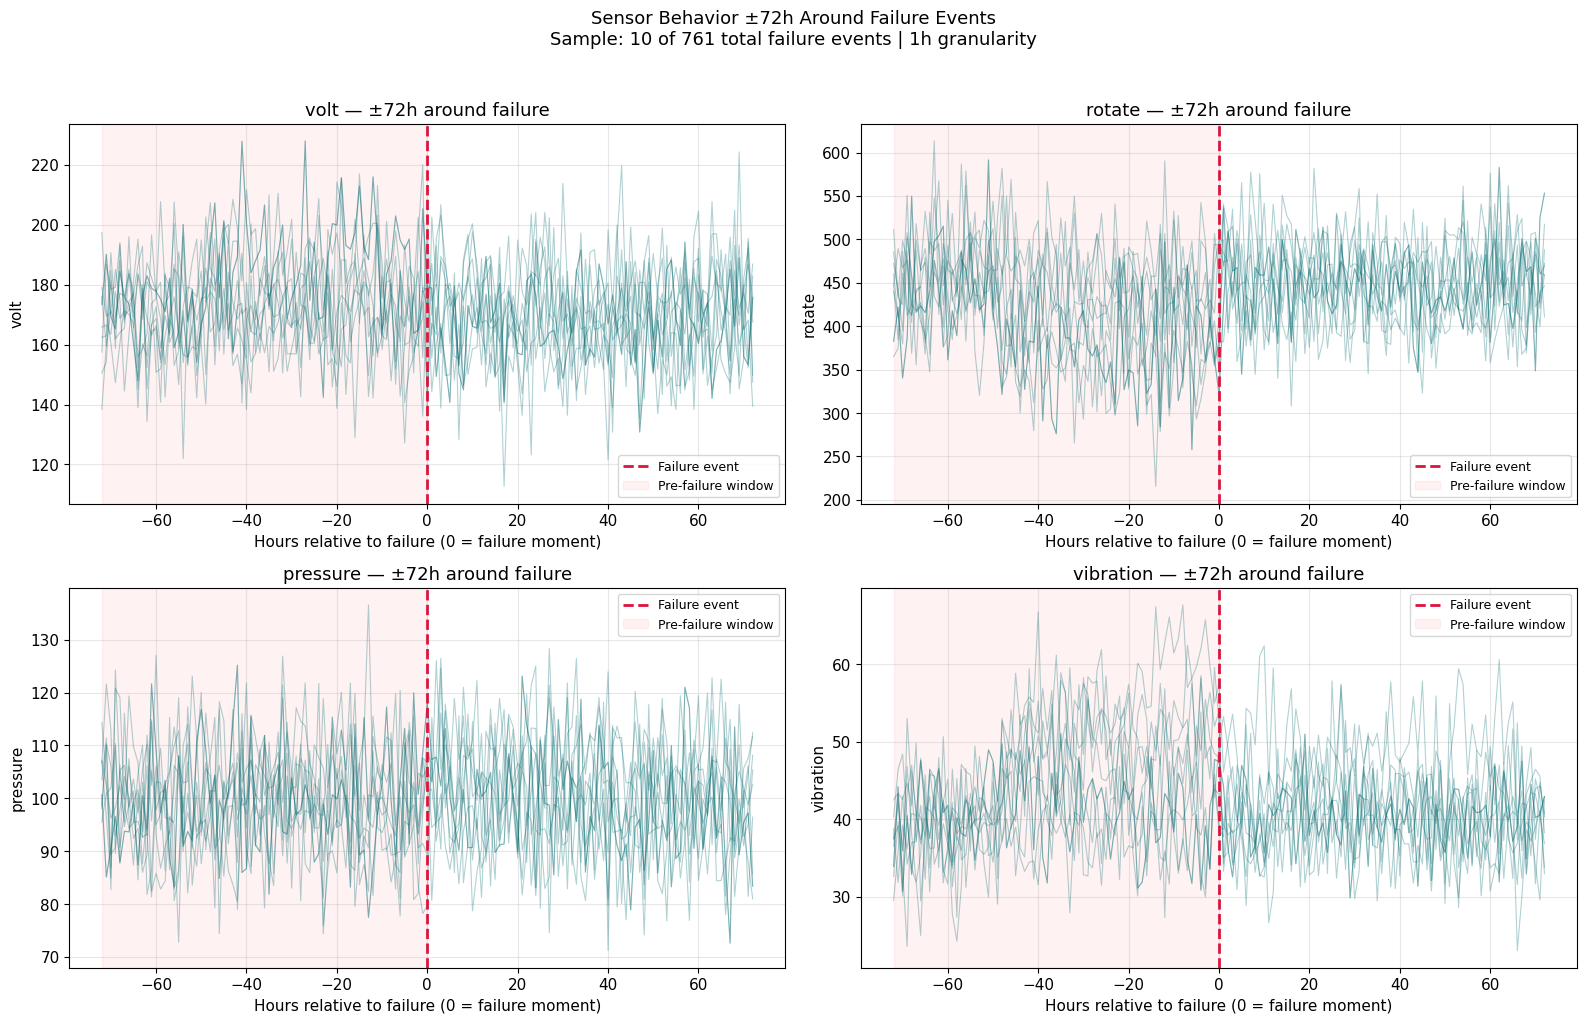

In [48]:
PRE_FAILURE_HOURS = 72
N_FAILURES_SAMPLE = min(10, failures.shape[0])   # ✅ no asumir que hay 10+
sample_failures   = failures.head(N_FAILURES_SAMPLE)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, sensor in zip(axes, sensors):
    for row in sample_failures.iter_rows(named=True):
        mid         = row["machineID"]
        fail_dt     = row["datetime"]
        window_start = fail_dt - timedelta(hours=PRE_FAILURE_HOURS)
        window_end   = fail_dt + timedelta(hours=PRE_FAILURE_HOURS)

        window = (
            telemetry
            .filter(
                (pl.col("machineID") == mid) &
                (pl.col("datetime") >= window_start) &
                (pl.col("datetime") <= window_end)
            )
            .sort("datetime")
            .with_columns(
                ((pl.col("datetime") - pl.lit(fail_dt)).dt.total_hours())
                .alias("hours_to_failure")
            )
        )
        if window.shape[0] > 0:
            hrs  = window["hours_to_failure"].to_numpy()
            vals = window[sensor].to_numpy()
            ax.plot(hrs, vals, alpha=0.3, linewidth=0.8, color="#01696f")

    ax.axvline(0, color="crimson", linestyle="--", linewidth=2, label="Failure event")
    ax.axvspan(-PRE_FAILURE_HOURS, 0, alpha=0.05, color="red", label="Pre-failure window")
    ax.set_title(f"{sensor} — ±{PRE_FAILURE_HOURS}h around failure")
    ax.set_xlabel("Hours relative to failure (0 = failure moment)")
    ax.set_ylabel(sensor)
    ax.legend(fontsize=9)

# ✅ Título completamente derivado del dato
plt.suptitle(
    f"Sensor Behavior ±{PRE_FAILURE_HOURS}h Around Failure Events\n"
    f"Sample: {N_FAILURES_SAMPLE} of {failures.shape[0]} total failure events | "
    f"{granularity_hours}h granularity",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_pre_failure_sensors.png", dpi=150, bbox_inches="tight")
plt.show()

In [50]:
# ── Análisis de mantenimiento ─────────────────────────────────────────────
print("Maintenance by component:")
maint_dist = (
    maint
    .group_by("comp")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
)
print(maint_dist)

# Intervalo promedio entre mantenimientos por componente
maint_intervals = (
    maint
    .sort(["machineID", "comp", "datetime"])
    .with_columns(
        pl.col("datetime")
          .shift(1)
          .over(["machineID", "comp"])
          .alias("prev_maint")
    )
    .filter(pl.col("prev_maint").is_not_null())
    .with_columns(
        ((pl.col("datetime") - pl.col("prev_maint")).dt.total_hours()).alias("hours_between")
    )
    .group_by("comp")
    .agg([
        pl.col("hours_between").mean().alias("avg_hours"),
        pl.col("hours_between").median().alias("median_hours"),
        pl.col("hours_between").std().alias("std_hours"),
    ])
    .sort("comp")
)

print("\nMaintenance intervals (hours):")
print(maint_intervals)
print("\nInsight: components with HIGH std have irregular maintenance → harder to model.")

Maintenance by component:
shape: (4, 2)
┌───────┬───────┐
│ comp  ┆ count │
│ ---   ┆ ---   │
│ str   ┆ u32   │
╞═══════╪═══════╡
│ comp2 ┆ 863   │
│ comp4 ┆ 811   │
│ comp3 ┆ 808   │
│ comp1 ┆ 804   │
└───────┴───────┘

Maintenance intervals (hours):
shape: (4, 4)
┌───────┬─────────────┬──────────────┬─────────────┐
│ comp  ┆ avg_hours   ┆ median_hours ┆ std_hours   │
│ ---   ┆ ---         ┆ ---          ┆ ---         │
│ str   ┆ f64         ┆ f64          ┆ f64         │
╞═══════╪═════════════╪══════════════╪═════════════╡
│ comp1 ┆ 1466.931818 ┆ 1080.0       ┆ 1431.165931 │
│ comp2 ┆ 1373.78768  ┆ 720.0        ┆ 1422.624203 │
│ comp3 ┆ 1488.135593 ┆ 1080.0       ┆ 1436.114128 │
│ comp4 ┆ 1479.324895 ┆ 1080.0       ┆ 1453.856182 │
└───────┴─────────────┴──────────────┴─────────────┘

Insight: components with HIGH std have irregular maintenance → harder to model.


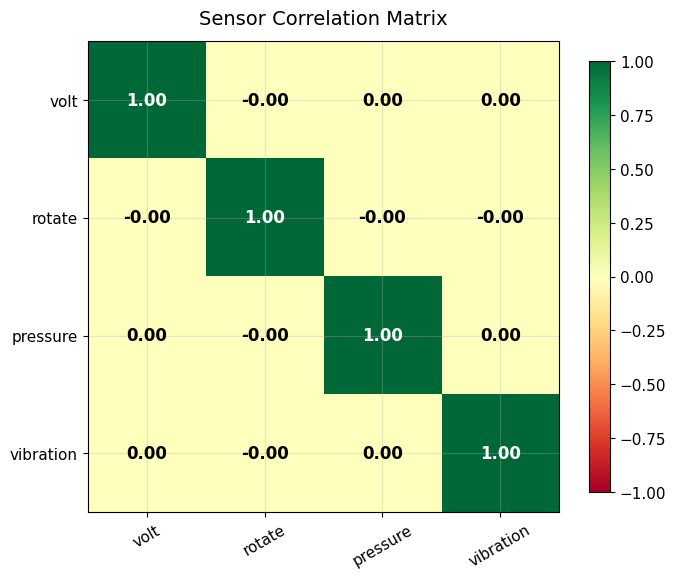

High correlation → redundant features. Low correlation → complementary signals.


In [51]:
# ── Correlación entre sensores ────────────────────────────────────────────
corr_matrix = telemetry.select(sensors).to_pandas().corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix.values, cmap="RdYlGn", vmin=-1, vmax=1)

ax.set_xticks(range(len(sensors)))
ax.set_yticks(range(len(sensors)))
ax.set_xticklabels(sensors, rotation=30)
ax.set_yticklabels(sensors)

for i in range(len(sensors)):
    for j in range(len(sensors)):
        val = corr_matrix.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=12, fontweight="bold",
                color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.85)
ax.set_title("Sensor Correlation Matrix", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("../data/processed/eda_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("High correlation → redundant features. Low correlation → complementary signals.")

CLASS BALANCE ANALYSIS
Total rows   :     34,706
Positives    :     17,184  (49.51%)
Negatives    :     17,522  (50.49%)
Ratio        : 1 : 1
scale_pos_weight = 1.0

Naive model accuracy (always predict 0): 50.49%
→ That model catches ZERO failures. PR-AUC exposes this.


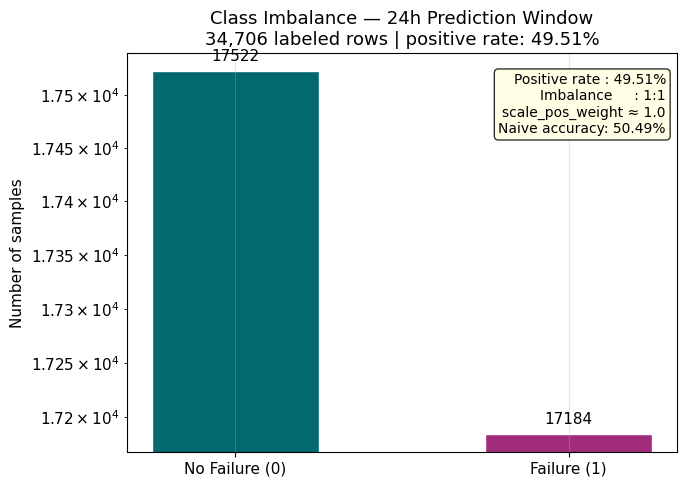

In [52]:
WINDOW_HOURS = 24

fail_times = failures.select(["machineID", "datetime"]).rename({"datetime": "fail_dt"})

labeled = (
    telemetry
    .join(fail_times, on="machineID", how="left")
    .filter(
        pl.col("fail_dt").is_null() | (
            (pl.col("fail_dt") > pl.col("datetime")) &
            (pl.col("fail_dt") <= pl.col("datetime") + pl.duration(hours=WINDOW_HOURS))
        )
    )
    .with_columns(
        pl.when(pl.col("fail_dt").is_not_null())
          .then(1).otherwise(0).cast(pl.Int8).alias("target")
    )
    .unique(subset=["machineID", "datetime"], keep="last")
)

# ✅ Todo derivado del dato
n_total_labeled = labeled.shape[0]
n_positive      = int(labeled["target"].sum())
n_negative      = n_total_labeled - n_positive
pos_rate        = n_positive / n_total_labeled * 100
neg_rate        = 100 - pos_rate
spw             = round(n_negative / max(n_positive, 1), 1)
naive_accuracy  = round(neg_rate, 2)

print("=" * 55)
print("CLASS BALANCE ANALYSIS")
print("=" * 55)
print(f"Total rows   : {n_total_labeled:>10,}")
print(f"Positives    : {n_positive:>10,}  ({pos_rate:.2f}%)")
print(f"Negatives    : {n_negative:>10,}  ({neg_rate:.2f}%)")
print(f"Ratio        : 1 : {int(n_negative // max(n_positive,1))}")
print(f"scale_pos_weight = {spw}")
print(f"\nNaive model accuracy (always predict 0): {naive_accuracy}%")
print("→ That model catches ZERO failures. PR-AUC exposes this.")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(
    ["No Failure (0)", "Failure (1)"],
    [n_negative, n_positive],
    color=["#01696f", "#a12c7b"],
    edgecolor="white", width=0.5,
)
ax.bar_label(bars, fmt="%d", padding=5, fontsize=11)
# ✅ Título y anotación completamente derivados del dato
ax.set_title(
    f"Class Imbalance — {WINDOW_HOURS}h Prediction Window\n"
    f"{n_total_labeled:,} labeled rows | positive rate: {pos_rate:.2f}%",
    fontsize=13
)
ax.set_ylabel("Number of samples")
ax.set_yscale("log")
ax.text(
    0.98, 0.95,
    f"Positive rate : {pos_rate:.2f}%\n"
    f"Imbalance     : 1:{int(n_negative // max(n_positive,1))}\n"
    f"scale_pos_weight ≈ {spw}\n"
    f"Naive accuracy: {naive_accuracy}%",
    transform=ax.transAxes, ha="right", va="top",
    fontsize=10, bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8)
)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "eda_class_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

In [53]:
# ✅ Resumen ejecutivo completamente dinámico — cero hardcoding
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  • {n_machines} machines | {span_days} days | {granularity_hours}h granularity          ║
║  • {telemetry.shape[0]:,} telemetry rows                            ║
║  • {failures.shape[0]} failure events | {errors.shape[0]:,} error events              ║
║                                                              ║
║  CLASS IMBALANCE                                             ║
║  • Positive rate : {pos_rate:.2f}% (with {WINDOW_HOURS}h window)              ║
║  • Ratio         : 1 : {int(n_negative // max(n_positive, 1))}                              ║
║  • scale_pos_weight ≈ {spw}                                ║
║  • → Use PR-AUC + F2-Score, NOT accuracy                    ║
║  • → Naive model gets {naive_accuracy:.1f}% accuracy (useless)          ║
║                                                              ║
║  TEMPORAL INTEGRITY                                          ║
║  • {date_start.strftime('%Y-%m-%d')} → {date_end.strftime('%Y-%m-%d')} ({span_days} days)             ║
║  • → Temporal split: train < 2015-10-01 | test >= 2015-10-01║
║                                                              ║
║  FEATURE ENGINEERING VALIDATED                               ║
║  • Windows _WINDOWS = [3, 24]   (hours, matches {granularity_hours}h data)  ║
║  • Lags    _LAGS    = [1, 2, 3] (hours, matches {granularity_hours}h data)  ║
║                                                              ║
║  NEXT STEP                                                   ║
║  • python pipelines/train_pipeline.py                        ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║           EDA SUMMARY — KEY FINDINGS                        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  DATASET                                                     ║
║  • 100 machines | 365 days | 1h granularity          ║
║  • 876,100 telemetry rows                            ║
║  • 761 failure events | 3,919 error events              ║
║                                                              ║
║  CLASS IMBALANCE                                             ║
║  • Positive rate : 49.51% (with 24h window)              ║
║  • Ratio         : 1 : 1                              ║
║  • scale_pos_weight ≈ 1.0                                ║
║  • → Use PR-AUC + F2-Score, NOT accuracy                    ║
║  • → Naive model gets 50.5% accuracy (useless)          ║
║                                                              ║
║ 